# Do the Dark Cloud & Piercing twins call the turn? 🌩️
### Two of candlestick lore's most-taught reversal patterns, measured honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

Open any candlestick textbook and you'll meet the **twins**. A **Piercing Line** is supposed to mark a *bottom*: a long red day, then a green day that gaps down at the open but rallies to close more than halfway back up the red body — a failed sell-off, so *buy*. A **Dark Cloud Cover** is the mirror — a long green day, then a red day that gaps up but sells off to close more than halfway down the green body — a failed rally, so *sell*. Do these twins actually predict the reversal?

> This is the plain-language layer. Want the HAC *t*-stats, the leg split, the placebo and the synthetic control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dark_cloud_piercing import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real(allow_fetch=False) if HAVE_REAL else None
print("real twin cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'fp': 'bf1d6cb7ca54', 'n_names': 30, 'n_events': 2342, 'n_bull': 1074, 'n_bear': 1268, 'h1': (1, 2342, -0.078, 0.028, 46.0, -2.57, -2.82, 0.998, -0.179), 'h3': (3, 2341, -0.097, 0.141, 47.2, -1.91, -1.81, 0.96, -0.2), 'h5': (5, 2341, -0.105, 0.253, 48.2, -1.49, -1.49, 0.924, -0.21), 'h10': (10, 2339, -0.069, 0.53, 49.3, -0.71, -0.68, 0.755, -0.179), 'bull': {1: (-0.033, -0.78, 47.0), 3: (0.11, 1.38, 51.0), 5: (0.306, 3.01, 54.3), 10: (0.481, 3.04, 56.9)}, 'bear': {1: (-0.116, -2.85, 45.1), 3: (-0.272, -3.98, 44.0), 5: (-0.453, -4.86, 43.1), 10: (-0.536, -3.91, 42.7)}, 'myth': [('plain', 2342, -0.078, -2.57, 46.0), ('+trend', 1243, -0.081, -1.92, 45.5), ('+volume spike', 190, -0.185, -1.88, 45.3), ('+both', 128, -0.011, -0.09, 48.4)], 'syn': [(0.0, 910, 0.021, 0.47, 0.313, 50.2), (0.004, 904, 0.414, 9.07, 0.0, 62.5)]}


real twin cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| Do the twins predict a reversal? | **No — they predict the opposite.** Signed return the day after is **-0.078%**, HAC *t* = **-2.57** (wrong sign). |
| Who's the culprit? | The **Dark Cloud (bearish) leg**: after it the stock keeps *rising* (1-day leg *t* = -2.85). |
| Is the Piercing (bullish) leg real alpha? | **No.** Its few-day gain is just the market's always-up drift — it barely beats buy-and-hold. |
| Could you trade it? | **No.** The gross edge is already negative; costs only deepen the hole. |

> The twins are a *story* about failed sell-offs and failed rallies. On 21 years of liquid US large-caps, the story runs backwards.

## 1 · The claim

> *"A **Piercing Line** marks a bottom: after a strong down day, price gaps lower but buyers take over and close it back above the midpoint of the prior body — a reversal up is coming. A **Dark Cloud Cover** marks a top: after a strong up day, price gaps higher but sellers take over and close it back below the midpoint — a reversal down is coming."*

These are textbook patterns from Steve Nison's *Japanese Candlestick Charting Techniques* — the work that brought candlesticks to the West. The twins are the 'almost-engulfing' cousins: deep penetration into the prior body, but not a full swallow. We test whether that penetration carries any forecasting power on modern US equities.

## 2 · So what?

If the twins reliably called turns, they'd be a free, mechanical entry signal anyone with a chart can read — no data feeds, no models. Millions of retail traders watch for exactly these shapes. If the premise is *wrong* — if a Dark Cloud is more often followed by more upside, not a top — then traders acting on the pattern are paying spreads to stand on the wrong side of the tape.

## 3 · How would we know?

One honest event study:

1. **Detect every twin by its exact OHLC rule** across a fixed 30-name basket (29 liquid large-caps + SPY), 2005–2026.
2. **Enter the next open** (one execution lag — no peeking at the close you traded on) and measure the forward 1 / 3 / 5 / 10-day return, *signed* by the pattern (long after a Piercing, short after a Dark Cloud).
3. **Compare to doing nothing** — the unconditional forward return on every bar of the same names — and to a **coin** (random bars, random direction, same count).

**What would make us say 'mirage':** if the signed return isn't reliably positive (HAC *t* ≥ 2) the reversal claim fails.

## 4 · The teardown — what actually happens

**The day after a twin, signed by the pattern direction.** If the reversal were real these bars would be green and above zero.

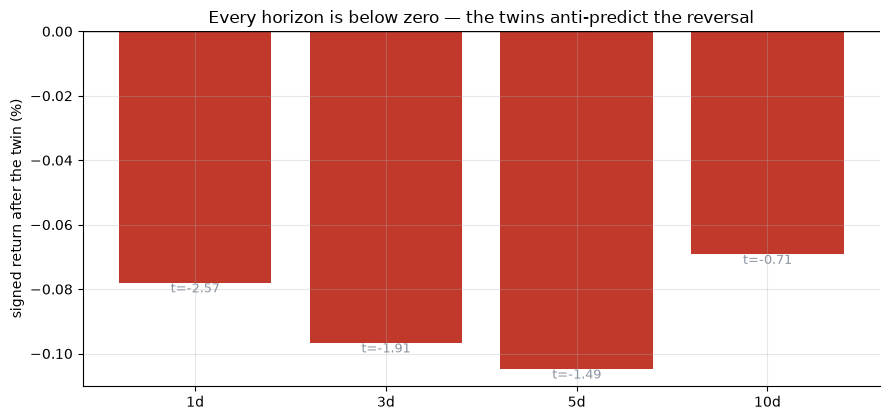

1-day: -0.078%  (HAC t = -2.57)


In [2]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, n_draws=2000) for h in horizons]
    means = [r['mean']*100 for r in rows]; tt = [r['t_hac'] for r in rows]
else:
    means = [R[f'h{h}'][2] for h in horizons]; tt = [R[f'h{h}'][5] for h in horizons]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in means]
ax.bar([f'{h}d' for h in horizons], means, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('signed return after the twin (%)')
ax.set_title('Every horizon is below zero — the twins anti-predict the reversal')
for x, (m, t) in enumerate(zip(means, tt)):
    ax.annotate(f't={t:+.2f}', (x, m), ha='center',
                va='top' if m < 0 else 'bottom', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'1-day: {means[0]:+.3f}%  (HAC t = {tt[0]:+.2f})')

The day-after signed return is **-0.078%** at HAC *t* = **-2.57** — significantly *negative*. The pattern doesn't fail to predict the reversal; it predicts the **wrong direction**. (At longer horizons the loss shrinks toward noise as the market's always-up drift reasserts itself.)

**Which twin is the problem?** Split the signed return into its two legs.

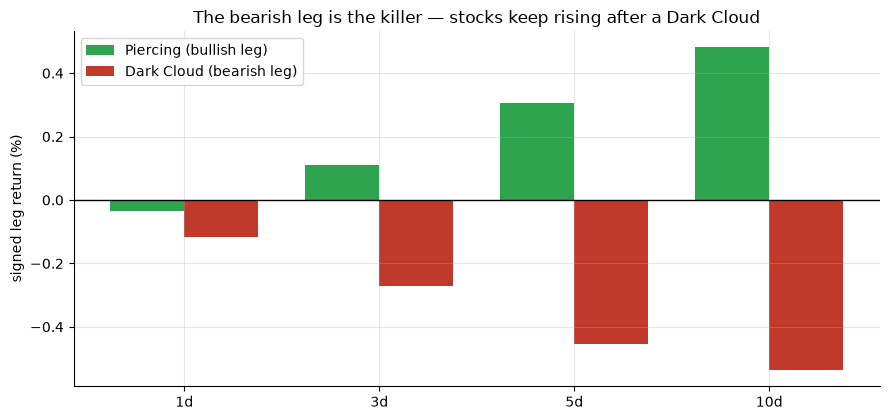

Dark Cloud short loses at every horizon; Piercing long is just the market drift.


In [3]:
if HAVE_REAL:
    legs = [st.leg_split(PANEL, h) for h in horizons]
    bull = [l['bull']['mean']*100 for l in legs]
    bear = [l['bear']['mean']*100 for l in legs]
else:
    bull = [R['bull'][h][0] for h in horizons]
    bear = [R['bear'][h][0] for h in horizons]
x = np.arange(len(horizons)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x - w/2, bull, w, color=GREEN, label='Piercing (bullish leg)')
ax.bar(x + w/2, bear, w, color=RED, label='Dark Cloud (bearish leg)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('signed leg return (%)'); ax.legend()
ax.set_title('The bearish leg is the killer — stocks keep rising after a Dark Cloud')
plt.tight_layout(); plt.show()
print('Dark Cloud short loses at every horizon; Piercing long is just the market drift.')

The **Dark Cloud (bearish) leg** is negative at every horizon — after the supposed 'top', stocks keep climbing, so the short bleeds. The **Piercing (bullish) leg** *looks* green over 5–10 days, but that's a trap: the unconditional 10-day long drift is **+0.530%**, and the Piercing leg earns only **+0.481%** — it **underperforms simply holding for a day**. No reversal alpha in either leg.

## 5 · The verdict

- **Signal — None.** Signed day-after return -0.078%, HAC *t* -2.57 (wrong sign); win-rate 46% (below a coin). Placebo *p* = 0.998 — almost every random pick beats the twins.
- **Tradability — Mirage.** The gross edge is negative before a cent of cost; round-trip + borrow only deepen the loss.
- **Reliable reversal? — Busted.** The bearish leg keeps rising and the bullish leg just rides beta. The twins don't mark turns on liquid US large-caps.

## 6 · Could you actually trade it?

There's nothing to trade. The gross is already below zero, so charging costs (a round trip per event, plus borrow on the short Dark Cloud leg) only widens the loss:

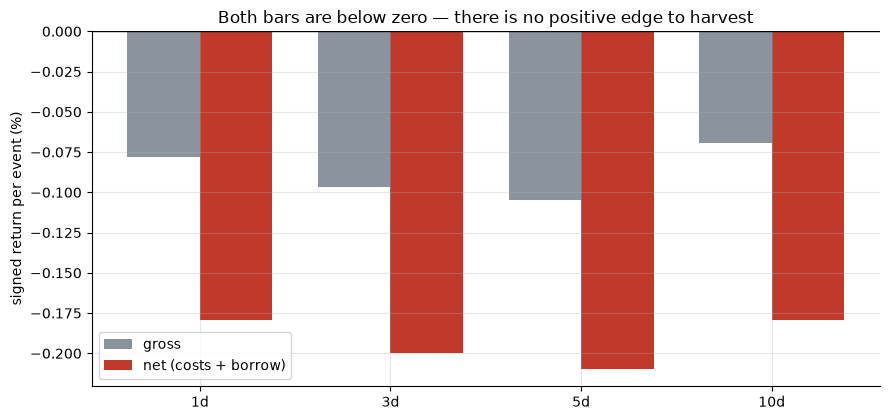

Gross is already negative — costs are not the killer, the signal is.


In [4]:
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, placebo=False) for h in horizons]
    gross = [r['mean']*100 for r in rows]; net = [r['net']*100 for r in rows]
else:
    gross = [R[f'h{h}'][2] for h in horizons]; net = [R[f'h{h}'][8] for h in horizons]
x = np.arange(len(horizons)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x - w/2, gross, w, color=GREY, label='gross')
ax.bar(x + w/2, net, w, color=RED, label='net (costs + borrow)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('signed return per event (%)'); ax.legend()
ax.set_title('Both bars are below zero — there is no positive edge to harvest')
plt.tight_layout(); plt.show()
print('Gross is already negative — costs are not the killer, the signal is.')

## 7 · Going further

- **The positive control.** The companion notebook plants a *real* day-after reversal in synthetic data — and the exact same test lights up at HAC *t* = +9.07. The machinery works; the market just doesn't cooperate.
- **The trend / volume caveat.** Textbooks say the twins only count *after a trend* and *on heavy volume*. The companion shows those filters don't flip the sign — they just throw events away.
- **The engulfing cousin.** [Study 402](../../402-engulfing-pattern/) tests the full real-body engulfing — the twins' bigger sibling — with the same backwards result.

*Think the twins work on a different asset, timeframe, or with a smarter confirmation rule? Fork this, change the detector or the basket, and show a signed reversal that clears HAC *t* ≥ 2. That is the bar.*